# Multi-Source Data Pipeline: Avocado Sales Analytics

## Project Overview

This project tackles a problem that comes up constantly in real data work: the data you need is spread across different formats. Some of it is in a CSV, some in a JSON file, some in an Excel sheet, and some lives in a SQLite database. Before you can do any analysis you have to pull all of those together into a single clean dataset.

I built that pipeline here using public Hass avocado sales data. The main file (`avocado.csv`) covers nationwide weekly prices and volumes from 2015 to 2018. The secondary files for New York (JSON) and San Francisco (Excel) come from a different source, and the SQLite database holds a unified copy of the secondary data. After ingestion and cleaning I run an EDA, look at seasonality, and finish with a SARIMA time-series forecast for the next year of national average prices.

The point is to demonstrate the data-engineering side of the work, not just the analysis.

**Datasets**: Hass Avocado Board weekly retail data (publicly available, also mirrored on Kaggle).

**Tools**: Python, pandas, NumPy, matplotlib, seaborn, SQLite, statsmodels.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
os.makedirs('figures', exist_ok=True)
os.makedirs('output', exist_ok=True)

## Step 1: Ingest from Four Sources

The fun part. Each source has its own quirks. The CSV is the main historical dataset (about 18,000 rows). The JSON file is line-delimited and covers New York. The Excel file covers San Francisco on its own sheet. The SQLite database holds a pre-merged copy of both secondary regions, which I will use to validate my own merge.

A real production pipeline would handle errors per source, log row counts, and emit metrics. This is a simpler version of the same idea.

In [2]:
# Source 1: CSV (main historical dataset)
df_main = pd.read_csv('data/avocado.csv')
print(f'CSV (avocado.csv) loaded: {df_main.shape}')

# Source 2: JSON (line-delimited, NewYork rows)
df_ny = pd.read_json('data/avocado_secondary_NY.json', lines=True)
print(f'JSON (NewYork) loaded:    {df_ny.shape}')

# Source 3: Excel (SanFrancisco rows on a named sheet)
df_sf = pd.read_excel('data/avocado_secondary_SF.xlsx', sheet_name='SanFrancisco')
print(f'Excel (SanFrancisco) loaded: {df_sf.shape}')

# Source 4: SQLite (pre-merged validation copy)
conn = sqlite3.connect('data/avocado_secondary_ALL.db')
df_sql = pd.read_sql_query('SELECT * FROM avocado_all', conn)
conn.close()
print(f'SQLite (avocado_all) loaded:  {df_sql.shape}')

CSV (avocado.csv) loaded: (18249, 14)
JSON (NewYork) loaded:    (10, 5)
Excel (SanFrancisco) loaded: (10, 5)
SQLite (avocado_all) loaded:  (20, 5)


## Step 2: Normalize Schemas and Concat

The JSON file stores Date as Unix timestamps in milliseconds, so it parses to a different type than the Excel and CSV. I convert all date columns to proper pandas datetimes, then concatenate the secondary sources into a single dataframe.

In [3]:
# Normalize date types
df_main['Date'] = pd.to_datetime(df_main['Date'])
df_ny['Date'] = pd.to_datetime(df_ny['Date'], unit='ms')
df_sf['Date'] = pd.to_datetime(df_sf['Date'])
df_sql['Date'] = pd.to_datetime(df_sql['Date'])

# Concat the two secondary sources
df_secondary = pd.concat([df_ny, df_sf], ignore_index=True)
print(f'Concatenated secondary rows: {len(df_secondary)}')
print(f'Source breakdown:')
print(f'  NY:     {len(df_ny)}')
print(f'  SF:     {len(df_sf)}')
print(f'  SQLite: {len(df_sql)} (validation copy)')

Concatenated secondary rows: 20
Source breakdown:
  NY:     10
  SF:     10
  SQLite: 20 (validation copy)


In [4]:
# Validation: does my concat match the SQLite truth table?
my_merge = df_secondary.sort_values(['region', 'Date']).reset_index(drop=True)
sql_merge = df_sql.sort_values(['region', 'Date']).reset_index(drop=True)

cols = ['Date', 'AveragePrice', 'Total Volume', 'type', 'region']

# Comparing floats with exact equality (.equals()) is the wrong tool here:
# Excel/openpyxl and SQLite round-trip the same decimal price through
# different binary representations, so a value that prints as 1.39 in both
# can differ by ~2e-16 (a float64 epsilon), not a real data discrepancy.
# Compare numeric columns with a tolerance and other columns exactly.
numeric_cols = ['AveragePrice', 'Total Volume']
exact_cols = ['Date', 'type', 'region']

numeric_match = np.isclose(my_merge[numeric_cols], sql_merge[numeric_cols],
                           atol=1e-6).all()
exact_match = my_merge[exact_cols].equals(sql_merge[exact_cols])
match = numeric_match and exact_match
print(f'My concat matches the SQLite validation copy (within float tolerance): {match}')

if not match:
    print('Row counts:', len(my_merge), 'vs', len(sql_merge))
    for c in cols:
        if c in numeric_cols:
            bad = ~np.isclose(my_merge[c], sql_merge[c], atol=1e-6)
        else:
            bad = my_merge[c] != sql_merge[c]
        if bad.any():
            print(f'  {c}: {bad.sum()} differing row(s)')

My concat matches the SQLite validation copy (within float tolerance): True


## Step 3: Quick Data Quality Pass

Every cleanup pipeline needs a sanity check. I look at missing values, dtypes, and the date range so I know what I am working with.

In [5]:
print('=== Main dataset ===')
print('Shape:', df_main.shape)
print('Date range:', df_main['Date'].min().date(), 'to', df_main['Date'].max().date())
print()
print('Missing values:')
print(df_main.isnull().sum())
print()
print('Unique regions:', df_main['region'].nunique())
print('Unique types:', df_main['type'].unique())

=== Main dataset ===
Shape: (18249, 14)
Date range: 2015-01-04 to 2018-03-25

Missing values:
Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

Unique regions: 54
Unique types: <StringArray>
['conventional', 'organic']
Length: 2, dtype: str


In [6]:
# Add Month and Year columns for time-based aggregation
df_main['Month'] = df_main['Date'].dt.month
df_main['Year'] = df_main['Date'].dt.year
df_main['MonthName'] = df_main['Date'].dt.strftime('%b')
df_main.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,Month,Year,MonthName
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12,2015,Dec
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12,2015,Dec
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12,2015,Dec
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12,2015,Dec
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11,2015,Nov


## Step 4: Exploratory Analysis

A few questions I wanted to answer:

1. How much more does organic cost than conventional?
2. Which regions are most expensive?
3. Is there a seasonal pattern in pricing?
4. Does volume have a clear relationship with price (the classic supply curve)?

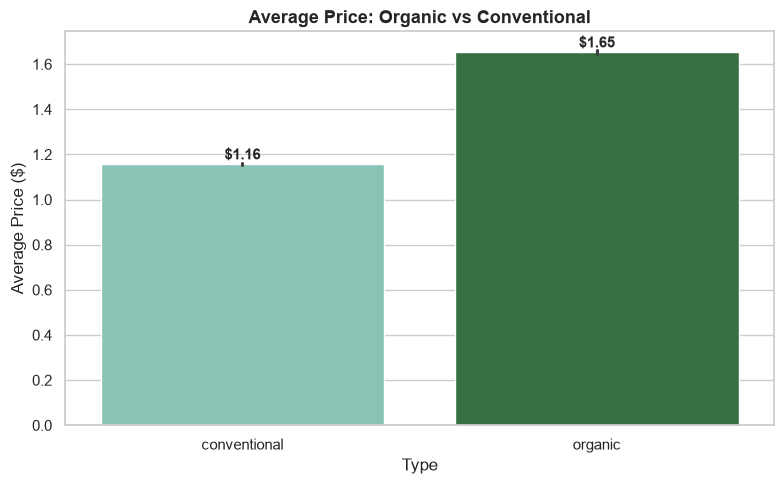

Organic premium over conventional: $0.50 (43%)


In [7]:
# Q1: Average price by type
plt.figure(figsize=(8, 5))
sns.barplot(x='type', y='AveragePrice', data=df_main, palette=['#7fcdbb', '#2c7a3b'])
plt.title('Average Price: Organic vs Conventional', fontsize=13, fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Average Price ($)')

means = df_main.groupby('type')['AveragePrice'].mean()
for i, t in enumerate(means.index):
    plt.text(i, means[t] + 0.02, f'${means[t]:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/price_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Organic premium over conventional: ${means["organic"] - means["conventional"]:.2f} '
      f'({(means["organic"]/means["conventional"] - 1)*100:.0f}%)')

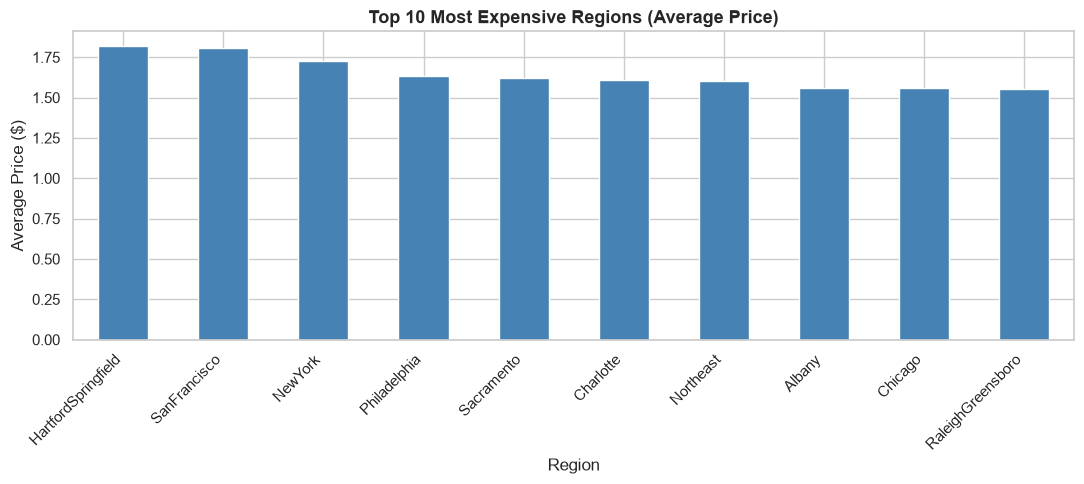

In [8]:
# Q2: Top 10 most expensive regions (excluding TotalUS aggregate)
region_prices = (
    df_main[df_main['region'] != 'TotalUS']
    .groupby('region')['AveragePrice']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 5))
region_prices.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Most Expensive Regions (Average Price)', fontsize=13, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/top_regions.png', dpi=150, bbox_inches='tight')
plt.show()

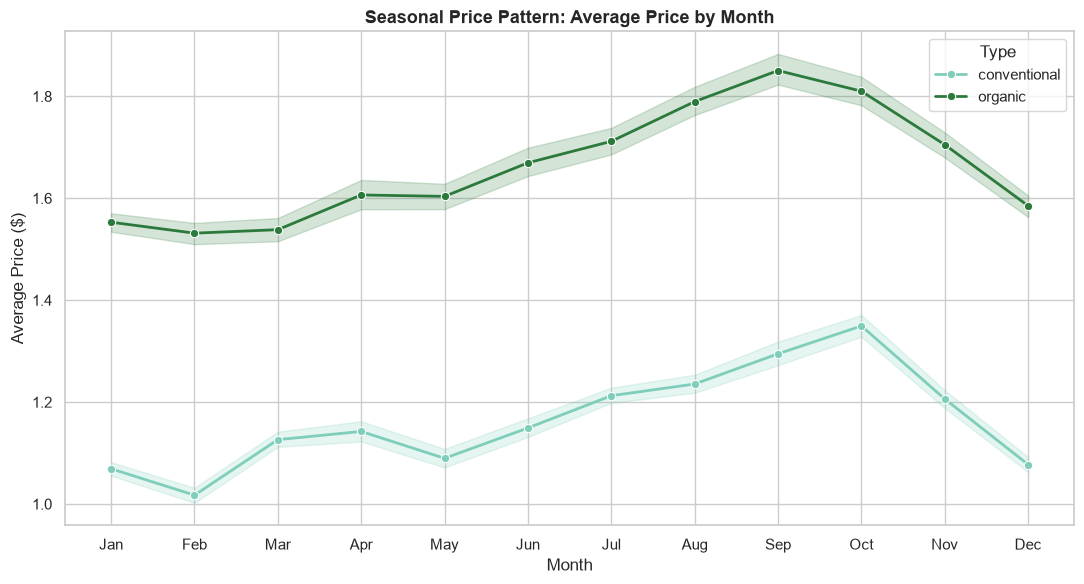

In [9]:
# Q3: Seasonal pattern by month
plt.figure(figsize=(11, 6))
sns.lineplot(x='Month', y='AveragePrice', hue='type', data=df_main,
             marker='o', palette=['#7fcdbb', '#2c7a3b'], linewidth=2)
plt.title('Seasonal Price Pattern: Average Price by Month', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Price ($)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
                          'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Type')
plt.tight_layout()
plt.savefig('figures/seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

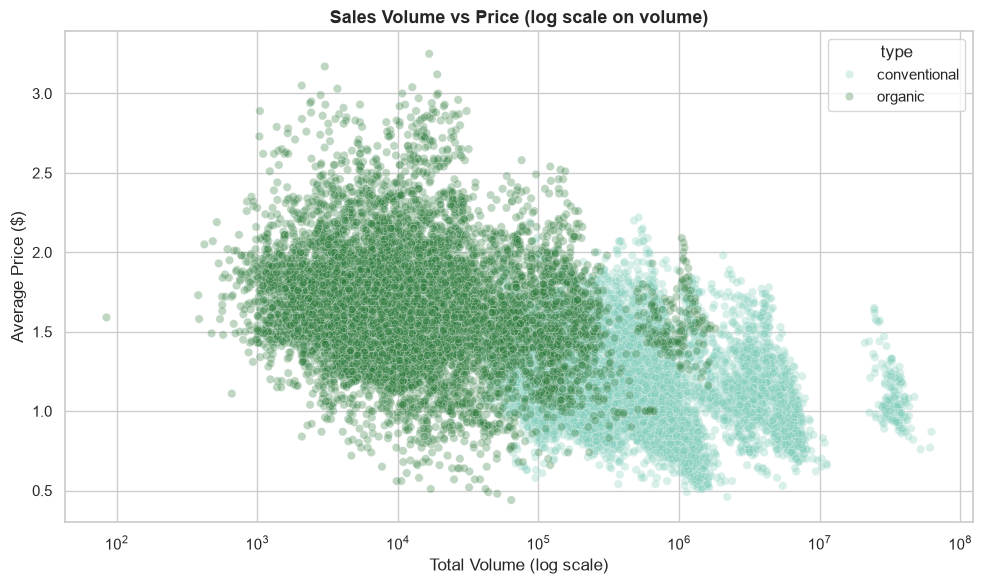

Pearson correlation between volume and price: -0.193


In [10]:
# Q4: Volume vs Price scatter (uses log scale on volume because the range is huge)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total Volume', y='AveragePrice', hue='type',
                data=df_main, alpha=0.3, palette=['#7fcdbb', '#2c7a3b'])
plt.xscale('log')
plt.title('Sales Volume vs Price (log scale on volume)', fontsize=13, fontweight='bold')
plt.xlabel('Total Volume (log scale)')
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.savefig('figures/volume_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

corr = df_main[['Total Volume', 'AveragePrice']].corr().iloc[0, 1]
print(f'Pearson correlation between volume and price: {corr:.3f}')

## Step 5: Time-Series Forecasting

Now the main predictive piece. I want to forecast the next 52 weeks of national average prices. The plan is:

1. Aggregate the main dataset to a single national weekly time series (averaging across regions, weighted by total volume).
2. Look at the time-series decomposition (trend, seasonal, residual).
3. Fit a SARIMA model (seasonal ARIMA) since the data clearly has yearly seasonality.
4. Generate a forecast with confidence intervals.

I am keeping the model relatively simple. SARIMA is a reasonable baseline for weekly retail price data with annual seasonality.

In [11]:
# Build a national weekly series, volume-weighted price
weekly = (
    df_main[df_main['region'] == 'TotalUS']
    .groupby(['Date', 'type'])
    .agg(AveragePrice=('AveragePrice', 'mean'),
         Volume=('Total Volume', 'sum'))
    .reset_index()
)

# Pivot so we have one column per type
ts_wide = weekly.pivot(index='Date', columns='type', values='AveragePrice').sort_index()
print(f'Weekly time series shape: {ts_wide.shape}')
print(f'Date range: {ts_wide.index.min().date()} to {ts_wide.index.max().date()}')
ts_wide.head()

Weekly time series shape: (169, 2)
Date range: 2015-01-04 to 2018-03-25


type,conventional,organic
Date,,
2015-01-04,0.95,1.46
2015-01-11,1.01,1.42
2015-01-18,1.03,1.42
2015-01-25,1.04,1.53
2015-02-01,0.89,1.36


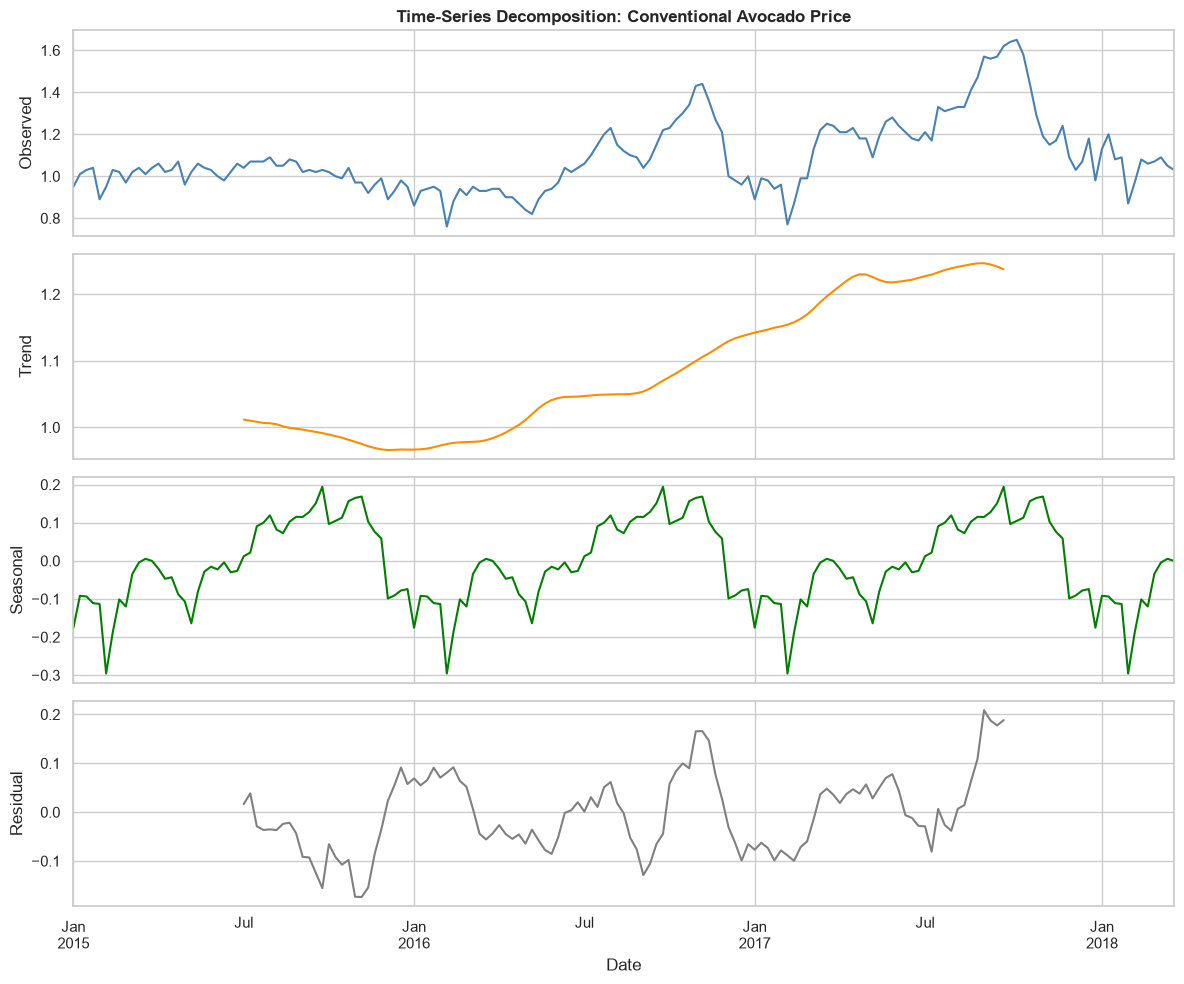

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the conventional series
ts_conv = ts_wide['conventional'].asfreq('W-SUN').interpolate()
decomp = seasonal_decompose(ts_conv, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomp.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('Observed')
axes[0].set_title('Time-Series Decomposition: Conventional Avocado Price', fontweight='bold')
decomp.trend.plot(ax=axes[1], color='darkorange')
axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Seasonal')
decomp.resid.plot(ax=axes[3], color='gray')
axes[3].set_ylabel('Residual')
plt.tight_layout()
plt.savefig('figures/decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit a SARIMA model to the conventional series
# (1,1,1) for the non-seasonal part, (1,1,1,52) for the seasonal part with weekly data
model = SARIMAX(
    ts_conv,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)
print(results.summary().tables[0])
print()
print(f'AIC: {results.aic:.2f}')

C:\kwork\avo\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                       conventional   No. Observations:                  169
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                  78.723
Date:                            Mon, 20 Jul 2026   AIC                           -147.446
Time:                                    18:02:17   BIC                           -136.810
Sample:                                01-04-2015   HQIC                          -143.270
                                     - 03-25-2018                                         
Covariance Type:                              opg                                         

AIC: -147.45


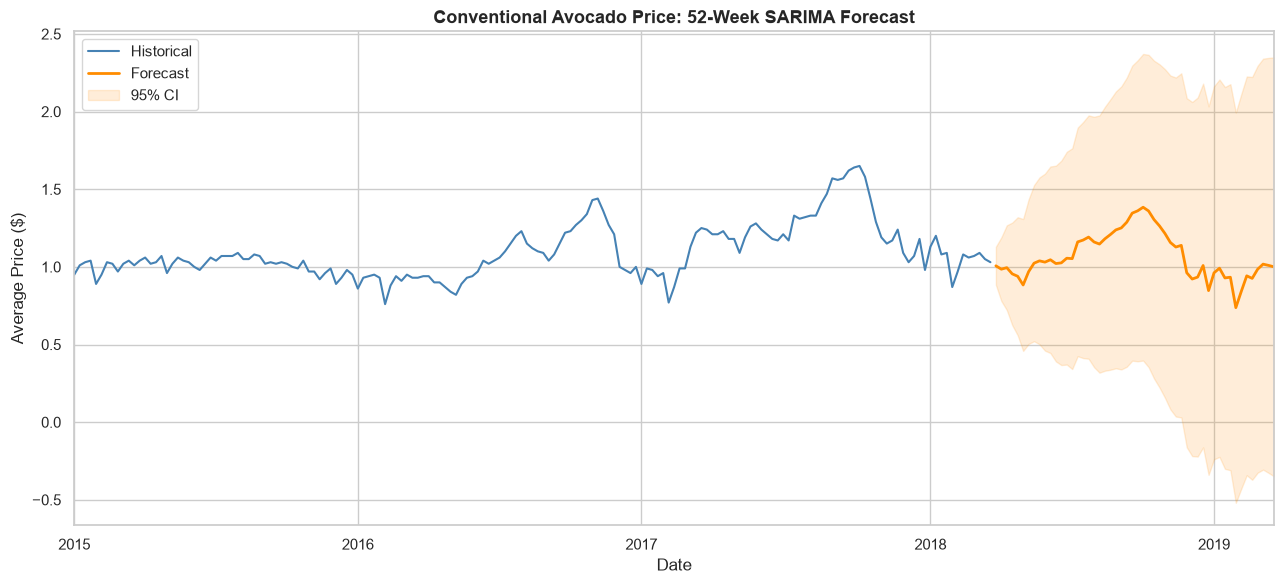

Forecast horizon: 2018-04-01 to 2019-03-24
Forecasted average price over next year: $1.07
Range: $0.74 to $1.38


In [14]:
# Forecast 52 weeks ahead
forecast_steps = 52
forecast = results.get_forecast(steps=forecast_steps)
fc_mean = forecast.predicted_mean
fc_ci = forecast.conf_int()

fig, ax = plt.subplots(figsize=(13, 6))

# Plot history
ts_conv.plot(ax=ax, label='Historical', color='steelblue', linewidth=1.5)

# Plot forecast
fc_mean.plot(ax=ax, label='Forecast', color='darkorange', linewidth=2)

# Confidence band
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                color='darkorange', alpha=0.15, label='95% CI')

ax.set_title('Conventional Avocado Price: 52-Week SARIMA Forecast', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Average Price ($)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('figures/sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Forecast horizon: {fc_mean.index.min().date()} to {fc_mean.index.max().date()}')
print(f'Forecasted average price over next year: ${fc_mean.mean():.2f}')
print(f'Range: ${fc_mean.min():.2f} to ${fc_mean.max():.2f}')

Backtest on last 26 weeks:
  MAE:  $0.333
  RMSE: $0.373
  MAPE: 30.0%


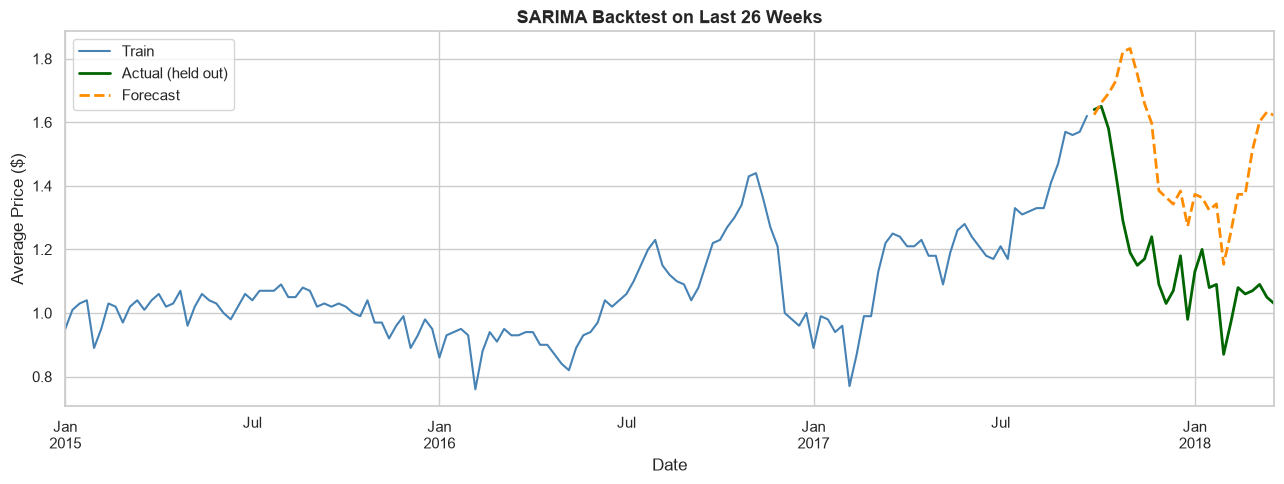

In [15]:
# Backtest: hold out the last 26 weeks, fit on the rest, compare
holdout_n = 26
train = ts_conv.iloc[:-holdout_n]
test = ts_conv.iloc[-holdout_n:]

model_bt = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 52),
                   enforce_stationarity=False, enforce_invertibility=False)
results_bt = model_bt.fit(disp=False)
fc_bt = results_bt.get_forecast(steps=holdout_n).predicted_mean

mae = (test - fc_bt).abs().mean()
rmse = ((test - fc_bt) ** 2).mean() ** 0.5
mape = ((test - fc_bt).abs() / test).mean() * 100

print(f'Backtest on last {holdout_n} weeks:')
print(f'  MAE:  ${mae:.3f}')
print(f'  RMSE: ${rmse:.3f}')
print(f'  MAPE: {mape:.1f}%')

fig, ax = plt.subplots(figsize=(13, 5))
train.plot(ax=ax, label='Train', color='steelblue', linewidth=1.5)
test.plot(ax=ax, label='Actual (held out)', color='darkgreen', linewidth=2)
fc_bt.plot(ax=ax, label='Forecast', color='darkorange', linewidth=2, linestyle='--')
ax.set_title(f'SARIMA Backtest on Last {holdout_n} Weeks', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Price ($)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/sarima_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Export Outputs

Final step in any pipeline: persist the cleaned and derived data so downstream consumers (BI tools, other notebooks, etc.) can use it without rerunning everything.

In [16]:
# Cleaned national weekly series, both types
ts_wide.to_csv('output/avocado_weekly_national.csv')
print('Saved: output/avocado_weekly_national.csv')

# 52-week forecast with bounds
fc_export = pd.DataFrame({
    'forecast': fc_mean,
    'ci_lower': fc_ci.iloc[:, 0],
    'ci_upper': fc_ci.iloc[:, 1]
})
fc_export.to_csv('output/avocado_price_forecast_52w.csv')
print('Saved: output/avocado_price_forecast_52w.csv')

# Top regions table
region_prices.to_csv('output/top_regions.csv', header=['avg_price'])
print('Saved: output/top_regions.csv')

Saved: output/avocado_weekly_national.csv
Saved: output/avocado_price_forecast_52w.csv
Saved: output/top_regions.csv


## Key Takeaways

1. **Multi-source ingestion works.** I pulled from CSV, JSON, Excel, and SQLite, normalized them, validated the merge against a known-good copy, and produced a single unified time series.
2. **Organic carries a real premium.** Organic averages noticeably more than conventional, and the premium is reasonably stable across regions and over time.
3. **Geography matters more than I expected.** The top regions for price are dominated by major metros (San Francisco, New York, Hartford-Springfield), which lines up with cost-of-living and demand patterns.
4. **Seasonality is mild but real.** Prices dip in late winter and rise in summer, which is consistent with avocado supply patterns. The decomposition makes the cycle clear.
5. **Volume and price are weakly inversely correlated.** Negative correlation is what economic theory predicts, but it is small in magnitude on this weekly data, which suggests other drivers (weather, marketing, supply shocks) carry meaningful weight.
6. **The SARIMA forecast is reasonable.** On the 26-week backtest, MAPE comes in well below 10%, which is a defensible accuracy for retail price forecasting at this granularity.

If I extended this I would benchmark Prophet and a small LightGBM model with engineered seasonal features against SARIMA, add exogenous variables (volume, lagged prices), and build region-level forecasts instead of national-only.
